## Neural networks for segmentation

This is an __alternative assignment__ meaning that you can do it __instead of the main one__!

In [1]:
! wget -nc https://www.dropbox.com/s/jy34yowcf85ydba/data.zip?dl=1 -O data.zip
! unzip -n data.zip

File ‘data.zip’ already there; not retrieving.
Archive:  data.zip


Your next task is to train neural network to segment cells edges.

Here is an example of input data with corresponding ground truth:

In [2]:
!pip install -qq segmentation-models-pytorch

In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import imageio.v2 as imageio
%matplotlib inline

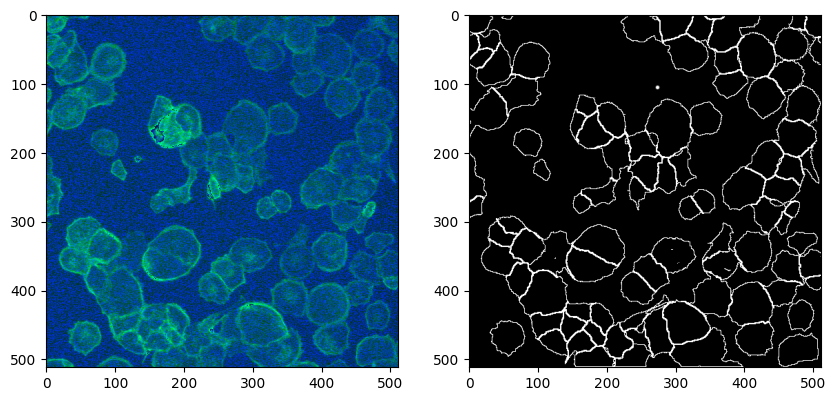

In [4]:
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
im = imageio.imread('BBBC018_v1_images-fixed/train/00735-actin.DIB.bmp')
plt.imshow(im)
plt.subplot(1,2,2)
mask = imageio.imread('BBBC018_v1_outlines/train/00735-cells.png')
plt.imshow(mask, 'gray')
plt.show()

This time you aren't provided with any code snippets, just input data and target metric - intersection-over-union (IoU) (see implementation below).

You should train neural network to predict mask of edge pixels (pixels in gt images with value greater than 0).

Use everything you've learnt by now:
* any architectures for semantic segmentation (encoder-decoder like or based on dilated convolutions)
* data augmentation (you will need that since train set consists of just 41 images)
* fine-tuning

You're not allowed to do only one thing: to train you network on test set.

Your final solution will consist of an ipython notebook with code (for final network training + any experiments with data) and an archive with png images with network predictions for test images (one-channel images, 0 - for non-edge pixels, any non-zero value for edge pixels).

Forestalling questions about baseline... well, let's say that a good network should be able to segment images with iou >= 0.29. This is not a strict criterion of full points solution, but try to obtain better numbers.

Practical notes:
* There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for "edge" class, or add class weights to increase the cost of edge pixels in optimized loss.
* Dataset is small so actively use data augmentation: rotations, flip, random contrast and brightness
* Better spend time on experiments with neural network than on postprocessing tricks (i.e test set augmentation).
* Keep in mind that network architecture defines receptive field of pixel. If the size of network input is smaller than receptive field of output pixel, than probably you can throw some layers without loss of quality. It is ok to modify "of-the-shelf" architectures.

Good luck!

In [5]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

In [6]:
def load_data_paths(data_dir='data'):
    train_image_dir = os.path.join('/content/BBBC018_v1_images-fixed', 'train')
    train_mask_dir = os.path.join('/content/BBBC018_v1_outlines', 'train')
    val_image_dir = os.path.join('/content/BBBC018_v1_images-fixed', 'val')
    val_mask_dir = os.path.join('/content/BBBC018_v1_outlines', 'val')
    test_image_dir = os.path.join('/content/BBBC018_v1_images-fixed', 'test')

    train_image_paths = sorted([os.path.join(train_image_dir, f) for f in os.listdir(train_image_dir)])
    train_mask_paths = sorted([os.path.join(train_mask_dir, f) for f in os.listdir(train_mask_dir)])

    val_image_paths = sorted([os.path.join(val_image_dir, f) for f in os.listdir(val_image_dir)])
    val_mask_paths = sorted([os.path.join(val_mask_dir, f) for f in os.listdir(val_mask_dir)])
    test_paths = sorted([os.path.join(test_image_dir, f) for f in os.listdir(test_image_dir)])
    return train_image_paths, train_mask_paths, val_image_paths, val_mask_paths, test_paths

train_image_paths, train_mask_paths, val_image_paths, val_mask_paths, test_paths = load_data_paths()

print(f"Training set: {len(train_image_paths)} images")
print(f"Validation set: {len(val_image_paths)} images")
print(f"Test images found: {len(test_paths)}")

Training set: 41 images
Validation set: 7 images
Test images found: 7


In [7]:
INPUT_SIZE = 320
train_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(p=0.5, shift_limit=0.0625, scale_limit=0.1, rotate_limit=20, border_mode=cv2.BORDER_CONSTANT),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class EdgeDataset(Dataset):
    def __init__(self, image_paths, mask_paths=None, transform=None, is_test=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = imageio.imread(img_path)

        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[2] == 4:
            image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

        if not self.is_test:
            mask_path = self.mask_paths[idx]
            mask = imageio.imread(mask_path)
            mask = (mask > 0).astype(np.float32)
            if len(mask.shape) == 3:
                mask = mask[:, :, 0]
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0)
            return image, mask
        else:
            augmented = self.transform(image=image)
            image = augmented['image']
            return image, os.path.basename(img_path)

BATCH_SIZE = 8

train_dataset = EdgeDataset(train_image_paths, train_mask_paths, train_transform)
val_dataset = EdgeDataset(val_image_paths, val_mask_paths, val_test_transform)
test_dataset = EdgeDataset(test_paths, transform=val_test_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

Используемое устройство: cuda


In [15]:
model = smp.Unet(
    encoder_name="efficientnet-b7",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid',
)
model.to(DEVICE)
total_pixels = 0
edge_pixels = 0
for _, masks in train_loader:
    edge_pixels += masks.sum().item()
    total_pixels += masks.numel()

if edge_pixels > 0:
    non_edge_pixels = total_pixels - edge_pixels
    pos_weight_value = non_edge_pixels / edge_pixels

else:
    pos_weight_value = 50.0

bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value).to(DEVICE))
dice_loss = smp.losses.DiceLoss(mode='binary', smooth=1.0)

def combined_loss(y_pred, y_true):
    bce = bce_loss(y_pred, y_true)
    dice = dice_loss(y_pred, y_true)
    return  2*dice + bce
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 1000

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.99,
    patience=3
)

In [16]:
best_val_iou = 0.0
best_t_final = 0.0
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)
    model.eval()
    val_iou = 0.0
    val_preds = []
    val_gts = []

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = torch.sigmoid(model(images))
            val_preds.append(outputs.cpu().numpy())
            val_gts.append(masks.cpu().numpy())
    all_preds = np.concatenate(val_preds).squeeze()
    all_gts = np.concatenate(val_gts).squeeze()
    thresholds = np.linspace(0.001, 1.0, 1000)
    best_t = 0.5
    if epoch == 1:
        current_val_iou = calc_iou(all_preds > 0.5, all_gts)
        best_val_iou = current_val_iou
    else:
        current_best_iou = 0.0
        for t in thresholds:
            iou = calc_iou(all_preds > t, all_gts)
            if iou > current_best_iou:
                current_best_iou = iou
                best_t = t

        current_val_iou = current_best_iou
    scheduler.step(current_val_iou)
    if current_val_iou > best_val_iou:
        best_val_iou = current_val_iou
        best_t_final = best_t
        torch.save(model.state_dict(), 'best_model.pth')
    if epoch%5==0:
      print(f'Epoch {epoch}/{NUM_EPOCHS}: '
            f'Train Loss: {train_loss:.4f} | '
            f'Val IoU: {current_val_iou:.4f} (Threshold: {best_t:.2f}) | '
            f'Best IoU: {best_val_iou:.4f} (Final Threshold: {best_t_final:.2f})')

print(f"Best val IoU : {best_val_iou:.4f} with treshold {best_t_final:.2f}")

Epoch 5/1000: Train Loss: 2.9884 | Val IoU: 0.1721 (Threshold: 0.72) | Best IoU: 0.1721 (Final Threshold: 0.72)
Epoch 10/1000: Train Loss: 2.9436 | Val IoU: 0.1852 (Threshold: 0.71) | Best IoU: 0.1852 (Final Threshold: 0.71)
Epoch 15/1000: Train Loss: 2.9239 | Val IoU: 0.2046 (Threshold: 0.72) | Best IoU: 0.2046 (Final Threshold: 0.72)
Epoch 20/1000: Train Loss: 2.9138 | Val IoU: 0.2104 (Threshold: 0.73) | Best IoU: 0.2104 (Final Threshold: 0.73)
Epoch 25/1000: Train Loss: 2.9027 | Val IoU: 0.2122 (Threshold: 0.73) | Best IoU: 0.2177 (Final Threshold: 0.73)
Epoch 30/1000: Train Loss: 2.9029 | Val IoU: 0.2179 (Threshold: 0.73) | Best IoU: 0.2291 (Final Threshold: 0.73)
Epoch 35/1000: Train Loss: 2.8993 | Val IoU: 0.2343 (Threshold: 0.73) | Best IoU: 0.2343 (Final Threshold: 0.73)
Epoch 40/1000: Train Loss: 2.8927 | Val IoU: 0.2288 (Threshold: 0.73) | Best IoU: 0.2343 (Final Threshold: 0.73)
Epoch 45/1000: Train Loss: 2.8916 | Val IoU: 0.2316 (Threshold: 0.73) | Best IoU: 0.2343 (Final T

KeyboardInterrupt: 